In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline

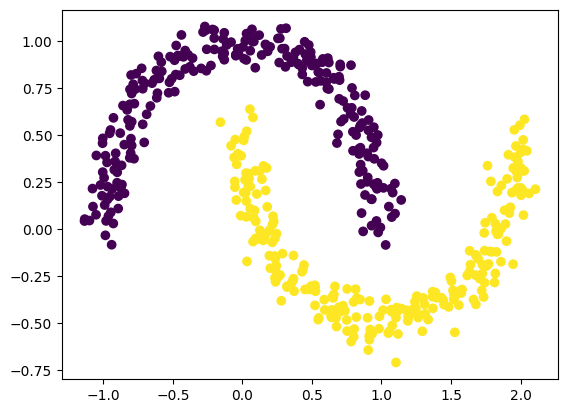

In [2]:
data = make_moons(500, noise=0.07, shuffle=True)
xs = [p[0] for p in data[0]]
ys = [p[1] for p in data[0]]
plt.scatter(xs, ys, c=data[1])

In [9]:
x_train, x_test, y_train, y_test = train_test_split(data[0], data[1], test_size=0.2, train_size=0.8)

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [ ]:
layers = [
    nn.Linear(2, 16),
    nn.Tanh(),
    nn.Linear(16, 16),
    nn.Tanh(),
    nn.Linear(16, 1),
    nn.Sigmoid()
]

criterion = nn.BCELoss()
optimizer = optim.SGD([p for layer in layers for p in layer.parameters()], lr=0.01)

In [15]:
losses = []

for i in tqdm(range(2000)):
    # forward
    out = x_train
    for layer in layers:
        out = layer(out)

    # loss
    loss = criterion(out, y_train)
    losses.append(loss.item())

    # grad reset
    optimizer.zero_grad()

    # backward
    loss.backward()

    # update
    optimizer.step()

100%|██████████| 2000/2000 [00:00<00:00, 4477.48it/s]


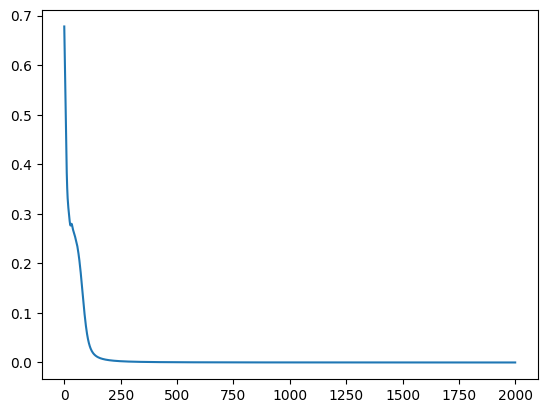

In [16]:
plt.plot(losses)

In [7]:
out = torch.tensor(data[0], dtype=torch.float32)
for x in layers:
    out = x.forward(out)

preds = [p.item() for p in out]
preds[:4]

[0.4891272187232971,
 0.4891272187232971,
 0.4887954592704773,
 0.4893683195114136]

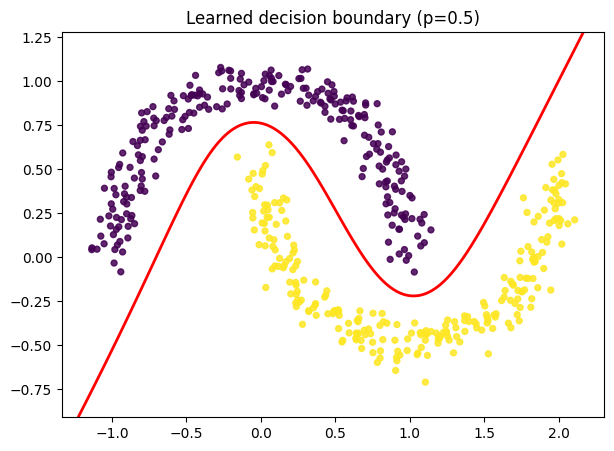

In [17]:
import numpy as np

plt.figure(figsize=(7, 5))
plt.scatter(xs, ys, c=data[1], s=18, alpha=0.85)

x_min, x_max = data[0][:, 0].min() - 0.2, data[0][:, 0].max() + 0.2
y_min, y_max = data[0][:, 1].min() - 0.2, data[0][:, 1].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    z = grid
    for layer in layers:
        z = layer(z)
    z = z.reshape(xx.shape).numpy()

plt.contour(xx, yy, z, levels=[0.5], colors='red', linewidths=2)
plt.title('Learned decision boundary (p=0.5)')
plt.show()

## Proper Reference Implementation (Clean Version)
A standard PyTorch binary-classification workflow end-to-end.

In [ ]:
# Proper way: reproducible setup + clean imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Reproducibility helps get consistent results across runs.
torch.manual_seed(42)
np.random.seed(42)

In [19]:
# 1) Data: create moons and split train/test
X, y = make_moons(n_samples=500, noise=0.07, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

# 2) Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Unsqueeze makes labels shape [N, 1] to match model output shape [N, 1].
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# 3) Model: standard Sequential MLP
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.Tanh(),
    nn.Linear(16, 16),
    nn.Tanh(),
    nn.Linear(16, 1),  # No Sigmoid here when using BCEWithLogitsLoss
 )

# 4) Loss + optimizer
criterion_ref = nn.BCEWithLogitsLoss()
optimizer_ref = optim.Adam(model.parameters(), lr=0.01)

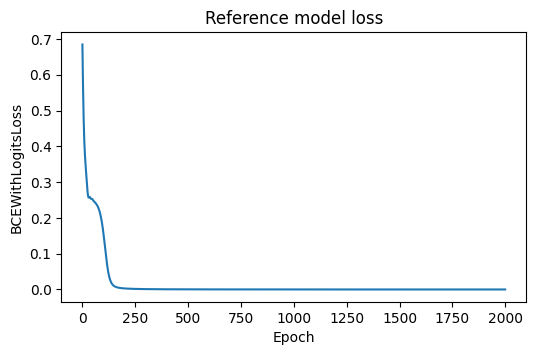

In [20]:
# 5) Training loop
losses_ref = []
epochs = 2000

for epoch in range(epochs):
    # Forward pass: raw logits from the model
    logits = model(X_train)

    # Compute binary classification loss
    loss = criterion_ref(logits, y_train)
    losses_ref.append(loss.item())

    # Backprop + parameter update
    optimizer_ref.zero_grad()
    loss.backward()
    optimizer_ref.step()

# Optional quick look at loss convergence
plt.figure(figsize=(6, 3.5))
plt.plot(losses_ref)
plt.title('Reference model loss')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.show()

In [21]:
# 6) Evaluation: convert logits -> probabilities -> classes
model.eval()
with torch.no_grad():
    train_logits = model(X_train)
    test_logits = model(X_test)

    train_probs = torch.sigmoid(train_logits)
    test_probs = torch.sigmoid(test_logits)

    train_preds = (train_probs >= 0.5).float()
    test_preds = (test_probs >= 0.5).float()

    train_acc = (train_preds.eq(y_train)).float().mean().item()
    test_acc = (test_preds.eq(y_test)).float().mean().item()

print(f'Train accuracy: {train_acc:.4f}')
print(f'Test accuracy:  {test_acc:.4f}')

Train accuracy: 1.0000
Test accuracy:  1.0000


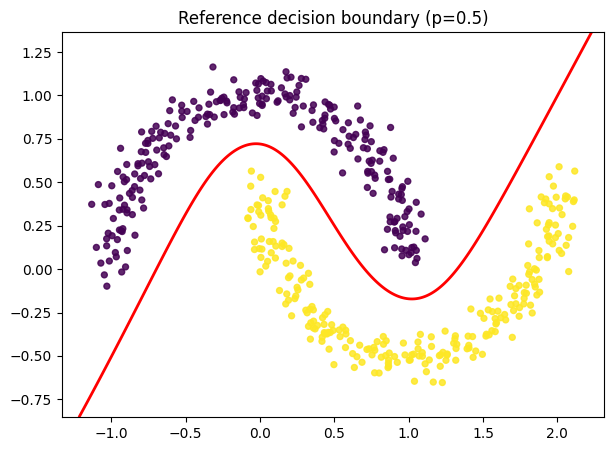

In [22]:
# 7) Plot decision boundary (p = 0.5 contour)
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    # Convert logits to probabilities for contouring at 0.5
    zz = torch.sigmoid(model(grid)).reshape(xx.shape).numpy()

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=18, alpha=0.85)
plt.contour(xx, yy, zz, levels=[0.5], colors='red', linewidths=2)
plt.title('Reference decision boundary (p=0.5)')
plt.show()